# EDA for `final_training_dataset_with_weather.parquet`

Simple pandas-based exploratory data analysis for the final training dataset after adding weather variables.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_training_dataset_with_weather.parquet"

print(DATA_PATH)
print(DATA_PATH.exists())

C:\Users\lefte\Desktop\GitHub Projects\Thesis_project\data\processed\final_training_dataset_with_weather.parquet
True


## Load Dataset

In [3]:
df = pd.read_parquet(DATA_PATH)
print(df.shape)
df.head()

(2000000, 22)


,rideable_type,started_at,member_casual,city,trip_duration,same_station,day_of_week,month,is_weekend,part_of_day,hour_sin,hour_cos,haversine_distance_km,bearing_sin,bearing_cos,hour,temperature_c,precipitation_mm,wind_speed_kph,snow_mm,rain_flag,snow_flag
0,classic_bike,2025-01-20 17:50:29.907,member,chicago,11.4833,0,0,1,0,evening_peak,-0.9659,-0.2588,2.3244,0.9722,-0.2341,17,-13.3000,0.0000,29.5000,0,0,0
1,classic_bike,2025-01-02 16:35:51.494,member,chicago,3.9000,0,3,1,0,evening_peak,-0.8660,-0.5000,0.6676,0.9747,-0.2235,16,-1.7000,0.0000,16.6000,0,0,0
2,classic_bike,2025-01-08 18:11:32.334,member,chicago,2.6667,0,2,1,0,evening_peak,-1.0000,-0.0000,0.4719,0.6360,-0.7717,18,-2.8000,0.0000,14.8000,0,0,0
3,classic_bike,2025-01-17 16:56:25.216,member,chicago,6.2333,0,4,1,0,evening_peak,-0.8660,-0.5000,1.2144,0.2582,-0.9661,16,2.8000,0.0000,33.5000,0,0,0
4,classic_bike,2025-01-03 18:39:50.561,member,chicago,8.3667,0,4,1,0,evening_peak,-1.0000,-0.0000,1.3157,1.0000,0.0010,18,-3.3000,0.0000,29.5000,0,0,0


## Basic Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   rideable_type          object        
 1   started_at             datetime64[us]
 2   member_casual          object        
 3   city                   object        
 4   trip_duration          float64       
 5   same_station           int32         
 6   day_of_week            int32         
 7   month                  int32         
 8   is_weekend             int32         
 9   part_of_day            object        
 10  hour_sin               float64       
 11  hour_cos               float64       
 12  haversine_distance_km  float64       
 13  bearing_sin            float64       
 14  bearing_cos            float64       
 15  hour                   int32         
 16  temperature_c          Float64       
 17  precipitation_mm       Float64       
 18  wind_speed_kph        

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
rideable_type,2000000,2,electric_bike,1341471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
started_at,2000000,NaN,NaN,NaN,2025-07-16 15:20:09.292655,2024-12-31 23:22:57.682000,2025-05-15 11:15:31.938750,2025-07-22 19:47:51.222500,2025-09-22 17:36:54.624250,2025-12-31 23:52:00.371000,NaN
member_casual,2000000,2,member,1477208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,2000000,2,chicago,1000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_duration,"2,000,000.0000",NaN,NaN,NaN,12.6243,1.0167,5.4333,9.2000,15.8000,99.9833,11.3332
same_station,"2,000,000.0000",NaN,NaN,NaN,0.0239,0.0000,0.0000,0.0000,0.0000,1.0000,0.1528
day_of_week,"2,000,000.0000",NaN,NaN,NaN,2.9871,0.0000,1.0000,3.0000,5.0000,6.0000,1.9494
month,"2,000,000.0000",NaN,NaN,NaN,6.9916,1.0000,5.0000,7.0000,9.0000,12.0000,2.8185
is_weekend,"2,000,000.0000",NaN,NaN,NaN,0.2731,0.0000,0.0000,0.0000,1.0000,1.0000,0.4455
part_of_day,2000000,4,evening_peak,656199,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values

In [6]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
missing["missing_pct"] = 100 * missing["missing_values"] / len(df)
missing

,missing_values,missing_pct
rideable_type,0,0.0000
started_at,0,0.0000
member_casual,0,0.0000
city,0,0.0000
trip_duration,0,0.0000
same_station,0,0.0000
day_of_week,0,0.0000
month,0,0.0000
is_weekend,0,0.0000
part_of_day,0,0.0000


## Weather Coverage by City

In [7]:
df.groupby("city").agg(
    n_rows=("city", "size"),
    missing_temperature=("temperature_c", lambda s: s.isna().sum()),
    min_started_at=("started_at", "min"),
    max_started_at=("started_at", "max"),
)

,n_rows,missing_temperature,min_started_at,max_started_at
city,,,,
chicago,1000000,0.0000,2024-12-31 23:22:57.682,2025-12-31 23:49:29.310
nyc,1000000,0.0000,2024-12-31 23:55:26.152,2025-12-31 23:52:00.371


## Categorical Distributions

In [8]:
categorical_cols = [
    "city",
    "rideable_type",
    "member_casual",
    "part_of_day",
    "is_weekend",
    "same_station",
    "rain_flag",
    "snow_flag",
    "month",
    "day_of_week",
    "hour",
]

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False).to_frame("count")
    counts["pct"] = 100 * counts["count"] / len(df)
    print(f"\n{col}")
    display(counts)


city


,count,pct
city,,
chicago,1000000,50.0000
nyc,1000000,50.0000



rideable_type


,count,pct
rideable_type,,
electric_bike,1341471,67.0735
classic_bike,658529,32.9265



member_casual


...

,count,pct
month,,
8,253291,12.6646
7,245026,12.2513
9,244489,12.2244
6,225551,11.2775
10,219745,10.9872
5,185210,9.2605
4,148918,7.4459
11,138946,6.9473
3,123527,6.1764



day_of_week


,count,pct
day_of_week,,
4,306441,15.3221
3,298909,14.9454
5,296120,14.8060
1,293083,14.6541
2,288920,14.4460
0,266481,13.3240
6,250046,12.5023



hour


,count,pct
hour,,
17,196091,9.8046
18,169396,8.4698
16,166555,8.3277
15,136620,6.8310
19,124157,6.2078
8,122821,6.1410
14,119025,5.9512
13,112808,5.6404
12,110115,5.5057


## Numeric Summary by City

In [9]:
numeric_cols = [
    "trip_duration",
    "haversine_distance_km",
    "temperature_c",
    "precipitation_mm",
    "wind_speed_kph",
    "snow_mm",
    "rain_flag",
    "snow_flag",
]

df.groupby("city")[numeric_cols].agg(["mean", "median", "std", "min", "max"]).round(4)

trip_duration                               haversine_distance_km  \
                 mean median     std    min     max                  mean   
city                                                                        
chicago       13.4186 9.6500 12.2777 1.0167 99.9667                2.2551   
nyc           11.8300 8.7667 10.2410 1.0167 99.9833                1.9835   

                                     temperature_c                          \
        median    std    min     max          mean  median    std      min   
city                                                                         
chicago 1.6726 1.8594 0.0000 11.9996       17.9772 20.0000 9.7374 -21.1000   
nyc     1.4924 1.6473 0.0000 11.9951       16.7101 18.0000 9.2201 -10.6000   

                precipitation_mm                              wind_speed_kph  \
            max             mean median    std    min     max           mean   
city                                                                           
chicago 35.6000           0.0725 0.0000 1.1427 0.0000 43.2000        15.1431   
nyc     37.8000           0.0494 0.0000 0.4675 0.0000 32.3000        17.1103   

                                      snow_mm                       rain_flag  \
         median    std    min     max    mean median    std min max      mean   
city                                                                            
chicago 14.8000 8.2892 0.0000 56.0000  0.0070 0.0000 0.1837   0   7    0.0338   
nyc     16.6000 8.8975 0.0000 59.4000  0.0019 0.0000 0.0604   0   4    0.0381   

                              snow_flag                        
        median    std min max      mean median    std min max  
city                                                           
chicago 0.0000 0.1808   0   1    0.0018 0.0000 0.0425   0   1  
nyc     0.0000 0.1915   0   1    0.0012 0.0000 0.0347   0   1

In [10]:
df.groupby("city")[["trip_duration", "haversine_distance_km", "temperature_c", "wind_speed_kph"]].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).round(4)

trip_duration  haversine_distance_km  temperature_c  \
city                                                                  
chicago 0.0100         1.6667                 0.0000        -8.9000   
        0.0500         2.8000                 0.3605        -0.6000   
        0.2500         5.7167                 1.0022        11.7000   
        0.5000         9.6500                 1.6726        20.0000   
        0.7500        16.5833                 2.9419        25.6000   
        0.9500        36.9500                 6.0734        31.1000   
        0.9900        65.5500                 9.0539        33.3000   
nyc     0.0100         1.4500                 0.0000        -5.0000   
        0.0500         2.4167                 0.3197         0.0000   
        0.2500         5.1667                 0.8595        10.0000   
        0.5000         8.7667                 1.4924        18.0000   
        0.7500        15.0333                 2.5895        23.9000   
        0.9500        31.3667                 5.3571        29.4000   
        0.9900        51.2500                 7.9624        33.9000   

                wind_speed_kph  
city                            
chicago 0.0100          0.0000  
        0.0500          0.0000  
        0.2500          9.4000  
        0.5000         14.8000  
        0.7500         20.0000  
        0.9500         30.0000  
        0.9900         38.9000  
nyc     0.0100          0.0000  
        0.0500          5.4000  
        0.2500         11.0000  
        0.5000         16.6000  
        0.7500         22.3000  
        0.9500         33.5000  
        0.9900         42.5000

## Weather Flags and Trip Behavior

In [11]:
df.groupby(["city", "rain_flag", "snow_flag"]).agg(
    n_rows=("city", "size"),
    avg_duration=("trip_duration", "mean"),
    median_duration=("trip_duration", "median"),
    avg_distance=("haversine_distance_km", "mean"),
    median_distance=("haversine_distance_km", "median"),
    avg_temperature=("temperature_c", "mean"),
    avg_wind_speed=("wind_speed_kph", "mean"),
).round(4)

n_rows  avg_duration  median_duration  \
city    rain_flag snow_flag                                          
chicago 0         0          964378       13.4406           9.6667   
                  1            1806        9.9532           7.5917   
        1         0           33816       12.9779           9.3833   
nyc     0         0          960709       11.8684           8.8000   
                  1            1173       10.1400           7.9000   
        1         0           38088       10.9140           8.1667   
                  1              30       10.7506           9.2000   

                             avg_distance  median_distance  avg_temperature  \
city    rain_flag snow_flag                                                   
chicago 0         0                2.2566           1.6743          18.0409   
                  1                1.7163           1.3101          -3.4136   
        1         0                2.2415           1.6606          17.3029   
nyc     0         0                1.9867           1.4946          16.7924   
                  1                1.7511           1.3442          -0.1858   
        1         0                1.9096           1.4360          15.1665   
                  1                1.7333           1.6539           0.8000   

                             avg_wind_speed  
city    rain_flag snow_flag                  
chicago 0         0                 15.1432  
                  1                 17.3317  
        1         0                 15.0252  
nyc     0         0                 17.1145  
                  1                 16.0256  
        1         0                 17.0405  
                  1                 11.4000

## Temperature Bands

In [12]:
df["temperature_band"] = pd.cut(
    df["temperature_c"],
    bins=[-float("inf"), 0, 10, 20, 30, float("inf")],
    labels=["< 0C", "0-10C", "10-20C", "20-30C", ">= 30C"],
)

df.groupby(["city", "temperature_band"], observed=True).agg(
    n_rows=("city", "size"),
    avg_duration=("trip_duration", "mean"),
    median_duration=("trip_duration", "median"),
    avg_distance=("haversine_distance_km", "mean"),
    median_distance=("haversine_distance_km", "median"),
).round(4)

n_rows  avg_duration  median_duration  avg_distance  \
city    temperature_band                                                        
chicago < 0C               56489        9.4993           6.9667        1.7596   
        0-10C             164355       11.1426           8.0000        2.0557   
        10-20C            290964       13.4589           9.5667        2.2643   
        20-30C            422517       14.5783          10.6833        2.3790   
        >= 30C             65675       14.8469          11.1167        2.3418   
nyc     < 0C               55112        9.2011           7.0167        1.6666   
        0-10C             202658       10.2353           7.6833        1.8243   
        10-20C            328377       11.8282           8.7833        2.0036   
        20-30C            375136       12.9989           9.7333        2.0927   
        >= 30C             38717       12.6083           9.4500        2.0398   

                          median_distance  
city    temperature_band                   
chicago < 0C                       1.3121  
        0-10C                      1.5090  
        10-20C                     1.6725  
        20-30C                     1.8066  
        >= 30C                     1.8223  
nyc     < 0C                       1.2719  
        0-10C                      1.3774  
        10-20C                     1.5085  
        20-30C                     1.5844  
        >= 30C                     1.5324

## Monthly Weather Patterns

In [13]:
monthly_weather = df.groupby(["city", "month"]).agg(
    n_rows=("city", "size"),
    avg_temperature=("temperature_c", "mean"),
    avg_precipitation=("precipitation_mm", "mean"),
    avg_wind_speed=("wind_speed_kph", "mean"),
    rain_rate=("rain_flag", "mean"),
    snow_rate=("snow_flag", "mean"),
    avg_duration=("trip_duration", "mean"),
    avg_distance=("haversine_distance_km", "mean"),
).reset_index()

monthly_weather.round(4)

,city,month,n_rows,avg_temperature,avg_precipitation,avg_wind_speed,rain_rate,snow_rate,avg_duration,avg_distance
0,chicago,1,25313,-3.1596,0.0618,18.4746,0.0250,0.0000,9.3663,1.7991
1,chicago,2,27803,-0.0839,0.0023,17.2577,0.0059,0.0000,9.5843,1.8379
2,chicago,3,54240,9.2198,0.0613,19.7866,0.0353,0.0000,11.9343,2.0909
3,chicago,4,67508,12.1259,0.0767,18.9988,0.0390,0.0000,12.1730,2.1506
4,chicago,5,90756,15.9683,0.0441,15.8737,0.0419,0.0000,13.5985,2.2797
5,chicago,6,121717,24.5945,0.0639,16.0806,0.0321,0.0000,14.9115,2.3772
6,chicago,7,136334,26.4506,0.3199,13.2915,0.0503,0.0000,14.7758,2.3550
7,chicago,8,141554,24.2495,0.0165,13.2318,0.0277,0.0000,15.0737,2.4003
8,chicago,9,128945,22.3100,0.0221,12.2952,0.0358,0.0000,13.8669,2.3670
9,chicago,10,116310,16.1001,0.0079,14.7398,0.0267,0.0000,12.7141,2.2219


## Plots on a Sample

In [14]:
sample_df = df.sample(min(100000, len(df)), random_state=42)
sample_df.shape

(100000, 23)

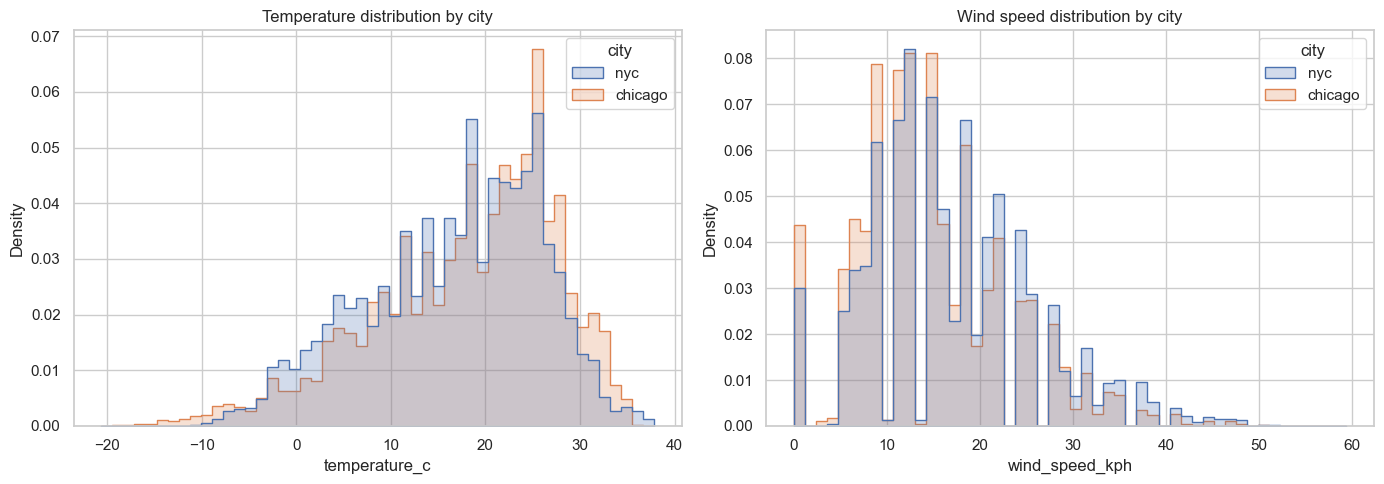

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=sample_df, x="temperature_c", hue="city", bins=50, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Temperature distribution by city")

sns.histplot(data=sample_df, x="wind_speed_kph", hue="city", bins=50, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Wind speed distribution by city")

plt.tight_layout()

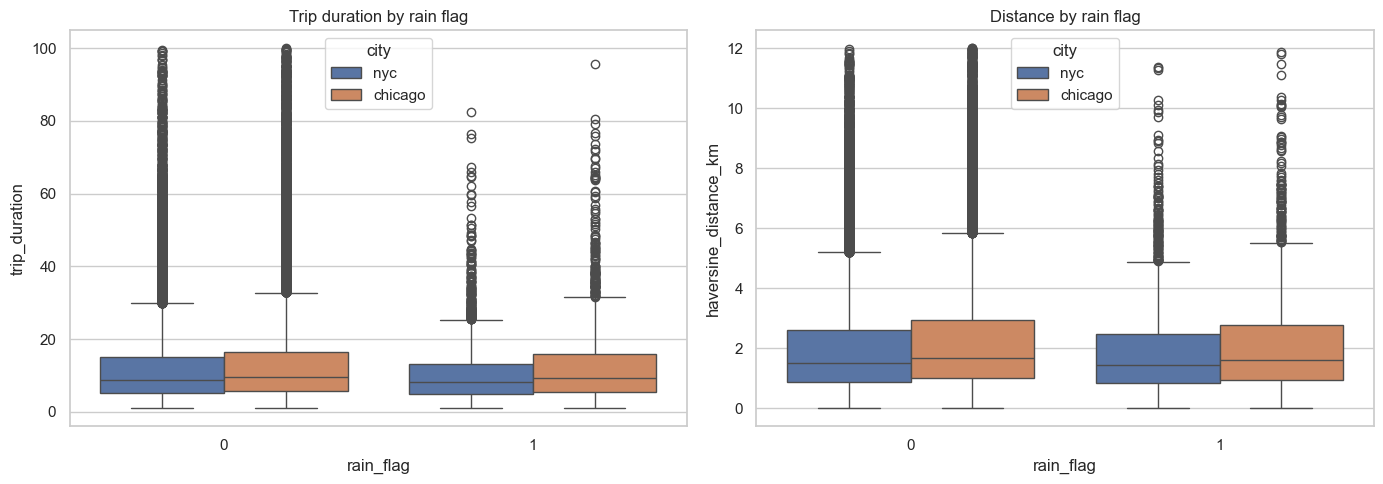

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=sample_df, x="rain_flag", y="trip_duration", hue="city", ax=axes[0])
axes[0].set_title("Trip duration by rain flag")

sns.boxplot(data=sample_df, x="rain_flag", y="haversine_distance_km", hue="city", ax=axes[1])
axes[1].set_title("Distance by rain flag")

plt.tight_layout()

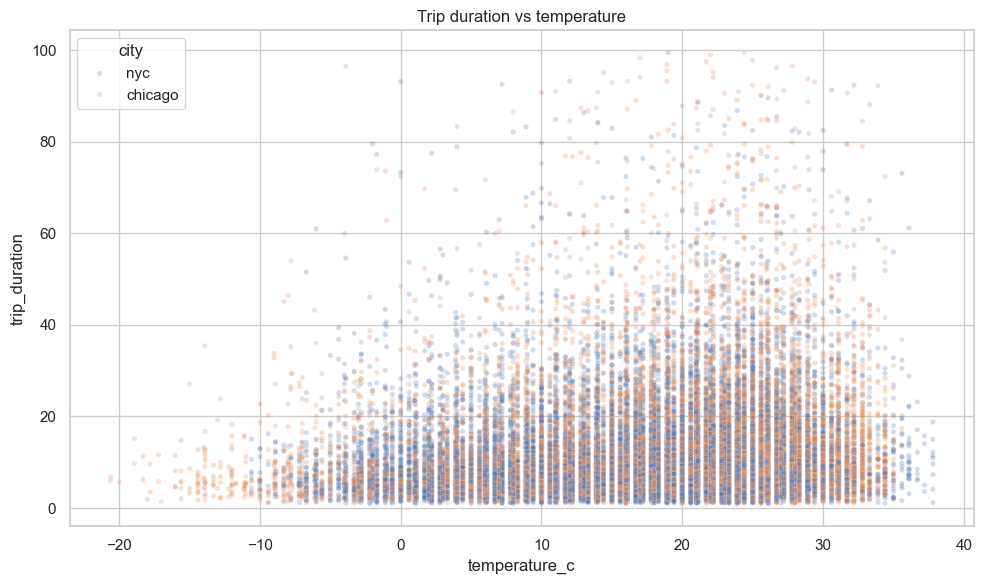

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df.sample(min(30000, len(sample_df)), random_state=42),
    x="temperature_c",
    y="trip_duration",
    hue="city",
    alpha=0.25,
    s=14,
)
plt.title("Trip duration vs temperature")
plt.tight_layout()

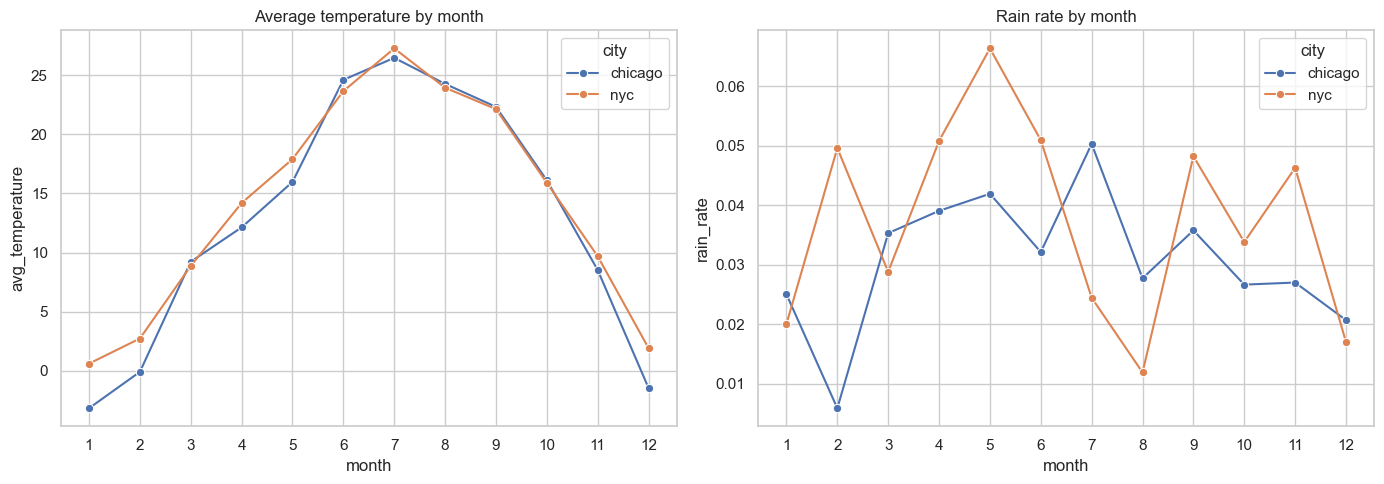

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=monthly_weather, x="month", y="avg_temperature", hue="city", marker="o", ax=axes[0])
axes[0].set_title("Average temperature by month")
axes[0].set_xticks(range(1, 13))

sns.lineplot(data=monthly_weather, x="month", y="rain_rate", hue="city", marker="o", ax=axes[1])
axes[1].set_title("Rain rate by month")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()

## Correlations

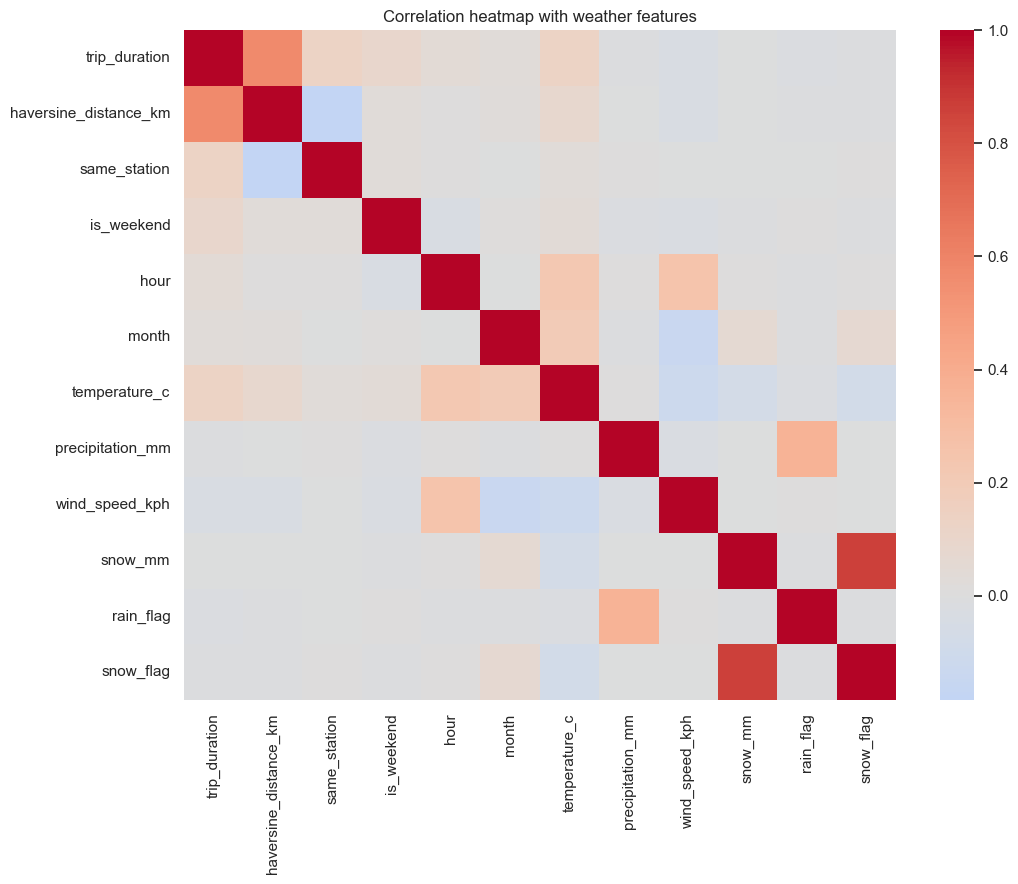

In [19]:
corr_cols = [
    "trip_duration",
    "haversine_distance_km",
    "same_station",
    "is_weekend",
    "hour",
    "month",
    "temperature_c",
    "precipitation_mm",
    "wind_speed_kph",
    "snow_mm",
    "rain_flag",
    "snow_flag",
]

corr = sample_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap with weather features")
plt.tight_layout()